In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import jax
import jax.numpy as jnp

import numpy as np
import healpy as hp
import pickle
from tqdm import tqdm

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

[gpu(id=0)]


In [2]:
sys.path.append("..")
from models.np_model import NPModel
from simulations.wrapper import simulator
from models.scd import dnds
from models.psf import KingPSF

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Get reasonable data values

In [5]:
s = pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))

In [6]:
for k in s:
    # if k.startswith('Alm') or k.startswith('n') or k.startswith('sb'):
    #     continue
    kshow = k.ljust(15)[:14]
    print(f'{kshow} : {np.median(s[k]):.3f}, {np.quantile(s[k], 0.18):.3f} - {np.quantile(s[k], 0.82):.3f}')

Alm_0          : -0.031, -0.042 - -0.012
Alm_1          : -0.002, -0.034 - 0.031
Alm_2          : -0.018, -0.033 - 0.002
Alm_3          : -0.006, -0.035 - 0.027
Alm_4          : -0.008, -0.023 - 0.009
Alm_5          : -0.003, -0.035 - 0.031
C              : 2.538, 2.015 - 3.195
S_bub          : 1.315, 1.232 - 1.396
S_dif          : 11.147, 10.992 - 11.279
S_gce          : 0.386, 0.288 - 0.516
S_ics          : 5.925, 5.775 - 6.086
S_iso          : 0.536, 0.423 - 0.680
S_psc          : 2.869, 1.558 - 3.996
Sps_dsk        : 1.015, 0.936 - 1.096
Sps_gce        : 1.086, 0.977 - 1.180
f_bulge_poiss  : 0.253, 0.173 - 0.357
f_bulge_ps     : 0.294, 0.216 - 0.387
gamma_poiss    : 0.924, 0.756 - 1.111
gamma_ps       : 1.211, 1.115 - 1.304
lambdas_dsk    : 0.414, 0.281 - 0.567
lambdas_gce    : 0.376, 0.254 - 0.518
n1_dsk         : 5.073, 4.537 - 5.585
n1_gce         : 5.524, 4.990 - 5.822
n2_dsk         : 1.358, 0.870 - 1.770
n2_gce         : 1.551, 1.191 - 1.800
n3_dsk         : -5.456, -5.776 - 

## 2. Poissonian realization

In [ ]:
save_dir = "../outputs/poiss_sim/np_p_230827"

npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [7]:
from simulations.simulate_poiss import simulate_mu

In [8]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    S_dsk = 0.0, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 1.2, f_bulge_poiss = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
)
mu = simulate_mu(npmodel, var_dict)
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))
np.save(f"{save_dir}/mu.npy", mu)

In [9]:
rng_key = jax.random.PRNGKey(42)

for i in tqdm(range(100)):
    rng_key, key = jax.random.split(rng_key)
    counts = jax.random.poisson(key, mu)
    np.save(f"{save_dir}/counts_{i}.npy", np.array(counts, dtype=np.int32))

100%|██████████| 100/100 [00:03<00:00, 32.31it/s]


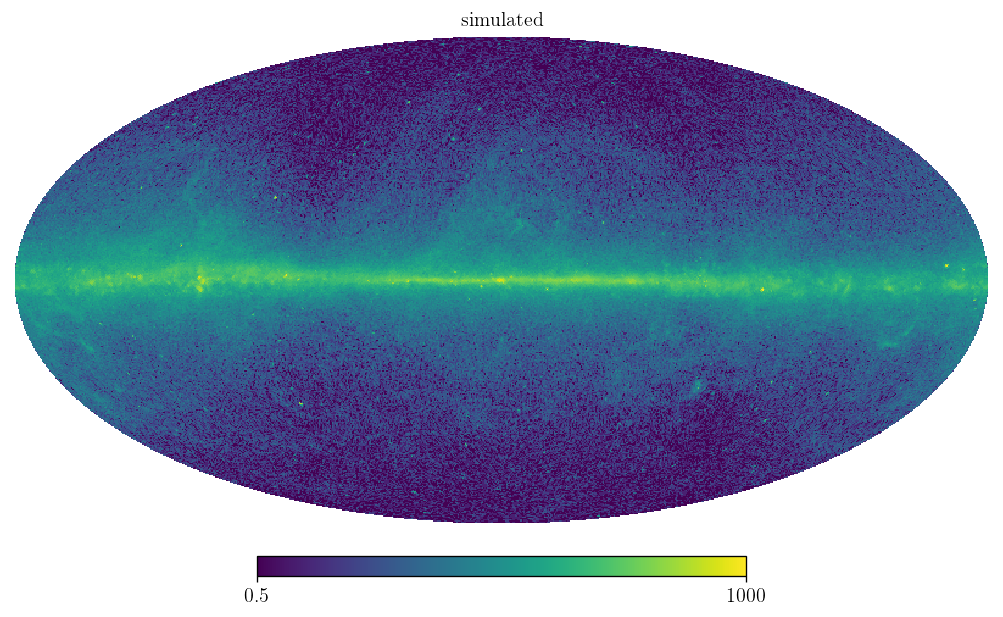

In [10]:
hp.mollview(jnp.clip(counts, 0.5, None), norm='log', max=1000, title='simulated')
plt.show()

## Non-poissonian

In [3]:
npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [5]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    Sps_dsk = 1.3, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 1.5, gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
)
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

In [4]:
save_dir = "../outputs/np_sim/230902"
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0., S_bub = 0., S_psc = 0., S_pib = 0., S_ics = 0.,
    Sps_dsk = 2., zs = 0.5, C = 2.5,
    S_gce = 0., gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 3., gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = np.array([0., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([1., 0., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
)
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

In [5]:
def wrapperwrapper(m: NPModel, vd: dict):

    # poiss: nfw iso bub psc pib*3 ics*3 blg*5
    nm = m.normalization_mask
    temps_poiss = [
        m.nfw_template.get_NFW2_template(gamma=vd['gamma_poiss']),
        m.temp_iso / np.mean(m.temp_iso[~nm]),
        m.temp_bub / np.mean(m.temp_bub[~nm]),
        m.temp_psc / np.mean(m.temp_psc[~nm]),
        m.pib[0] / np.mean(m.pib[0][~nm]),
        m.pib[1] / np.mean(m.pib[1][~nm]),
        m.pib[2] / np.mean(m.pib[2][~nm]),
        m.ics[0] / np.mean(m.ics[0][~nm]),
        m.ics[1] / np.mean(m.ics[1][~nm]),
        m.ics[2] / np.mean(m.ics[2][~nm]),
        m.bulge_templates[0] / np.mean(m.bulge_templates[0][~nm]),
        m.bulge_templates[1] / np.mean(m.bulge_templates[1][~nm]),
        m.bulge_templates[2] / np.mean(m.bulge_templates[2][~nm]),
        m.bulge_templates[3] / np.mean(m.bulge_templates[3][~nm]),
        m.bulge_templates[4] / np.mean(m.bulge_templates[4][~nm]),
    ]
    temps_poiss = [np.array(t) for t in temps_poiss]
    theta = [
        vd['S_gce'] * (1 - vd['f_bulge_poiss']),
        vd['S_iso'],
        vd['S_bub'],
        vd['S_psc'],
        vd['S_pib'] * vd['theta_pib'][0],
        vd['S_pib'] * vd['theta_pib'][1],
        vd['S_pib'] * vd['theta_pib'][2],
        vd['S_ics'] * vd['theta_ics'][0],
        vd['S_ics'] * vd['theta_ics'][1],
        vd['S_ics'] * vd['theta_ics'][2],
        vd['S_gce'] * vd['f_bulge_poiss'] * vd['theta_bulge_poiss'][0],
        vd['S_gce'] * vd['f_bulge_poiss'] * vd['theta_bulge_poiss'][1],
        vd['S_gce'] * vd['f_bulge_poiss'] * vd['theta_bulge_poiss'][2],
        vd['S_gce'] * vd['f_bulge_poiss'] * vd['theta_bulge_poiss'][3],
        vd['S_gce'] * vd['f_bulge_poiss'] * vd['theta_bulge_poiss'][4],
    ]

    # ps: nfw+blg*5 dsk
    temp_ps_nfw = m.nfw_template.get_NFW2_template(gamma=vd['gamma_poiss'])
    temp_ps_blg = np.einsum('i,ij->j', vd['theta_bulge_ps'], m.bulge_templates)
    A_gce_nfw = 1 / np.mean(temp_ps_nfw[~nm])
    A_gce_blg = 1 / np.mean(temp_ps_blg[~nm])
    temp_ps_gce = (1 - vd['f_bulge_ps']) * A_gce_nfw * temp_ps_nfw + vd['f_bulge_ps'] * A_gce_blg * temp_ps_blg

    temp_ps_dsk = m.disk_template.get_template(zs=vd['zs'], C=vd['C'])
    temps_ps = [
        temp_ps_gce,
        temp_ps_dsk,
    ]
    temps_ps = [np.array(t) for t in temps_ps]
    # A_gce, A_dsk
    s_ary = np.logspace(0., 2., 100)
    theta_tmp = np.array([1., vd['n1_gce'], vd['n2_gce'], vd['n3_gce'], vd['sb1_gce'], vd['lambdas_gce'] * vd['sb1_gce']])
    dnds_ary = dnds(s_ary, theta_tmp)
    A_gce = vd['Sps_gce'] / np.mean(temp_ps_gce[~nm] * np.trapz(s_ary * dnds_ary, s_ary))
    theta_tmp = np.array([1., vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['lambdas_dsk'] * vd['sb1_dsk']])
    dnds_ary = dnds(s_ary, theta_tmp)
    A_dsk = vd['Sps_dsk'] / np.mean(temp_ps_dsk[~nm] * np.trapz(s_ary * dnds_ary, s_ary))
    theta += [
        A_gce, vd['n1_gce'], vd['n2_gce'], vd['n3_gce'], vd['sb1_gce'], vd['lambdas_gce'] * vd['sb1_gce'],
        A_dsk, vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['lambdas_dsk'] * vd['sb1_dsk'],
    ]

    mask_sim = np.zeros_like(m.data, dtype=bool) # simulate all
    mask_normalize_counts = np.array(m.normalization_mask)
    mask_roi = np.array(m.mask_roi)
    #mask_roi = None

    kp = KingPSF()
    psf_r_func = lambda r: kp.psf_fermi_r(r)
    exp_map = np.array(m.exposure_map)

    return simulator(theta, temps_poiss, temps_ps, mask_sim, mask_normalize_counts, mask_roi, psf_r_func, exp_map)[0]

In [6]:
counts = wrapperwrapper(npmodel, var_dict)

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3652: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


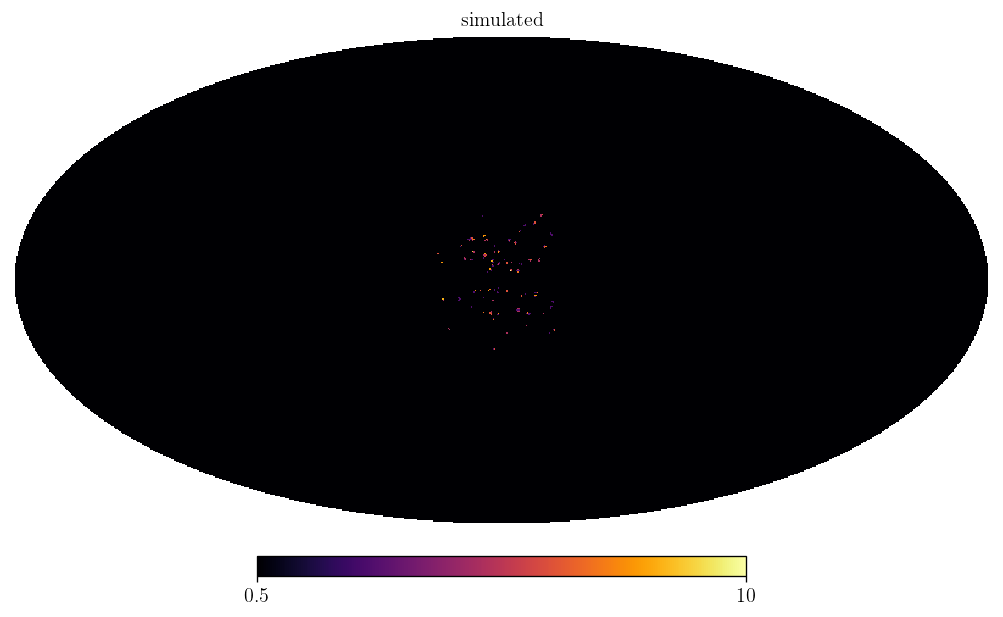

In [11]:
hp.mollview(np.clip(counts, 0.5, None), norm='log', title='simulated', cmap='inferno')
plt.show()

In [8]:
np.save(f"{save_dir}/counts_0.npy", np.array(counts, dtype=np.int32))